In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\anyab\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer


In [4]:
df = pd.read_csv('Walmart.csv')

In [5]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [6]:
print(df.info())
print('\n')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB
None


Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


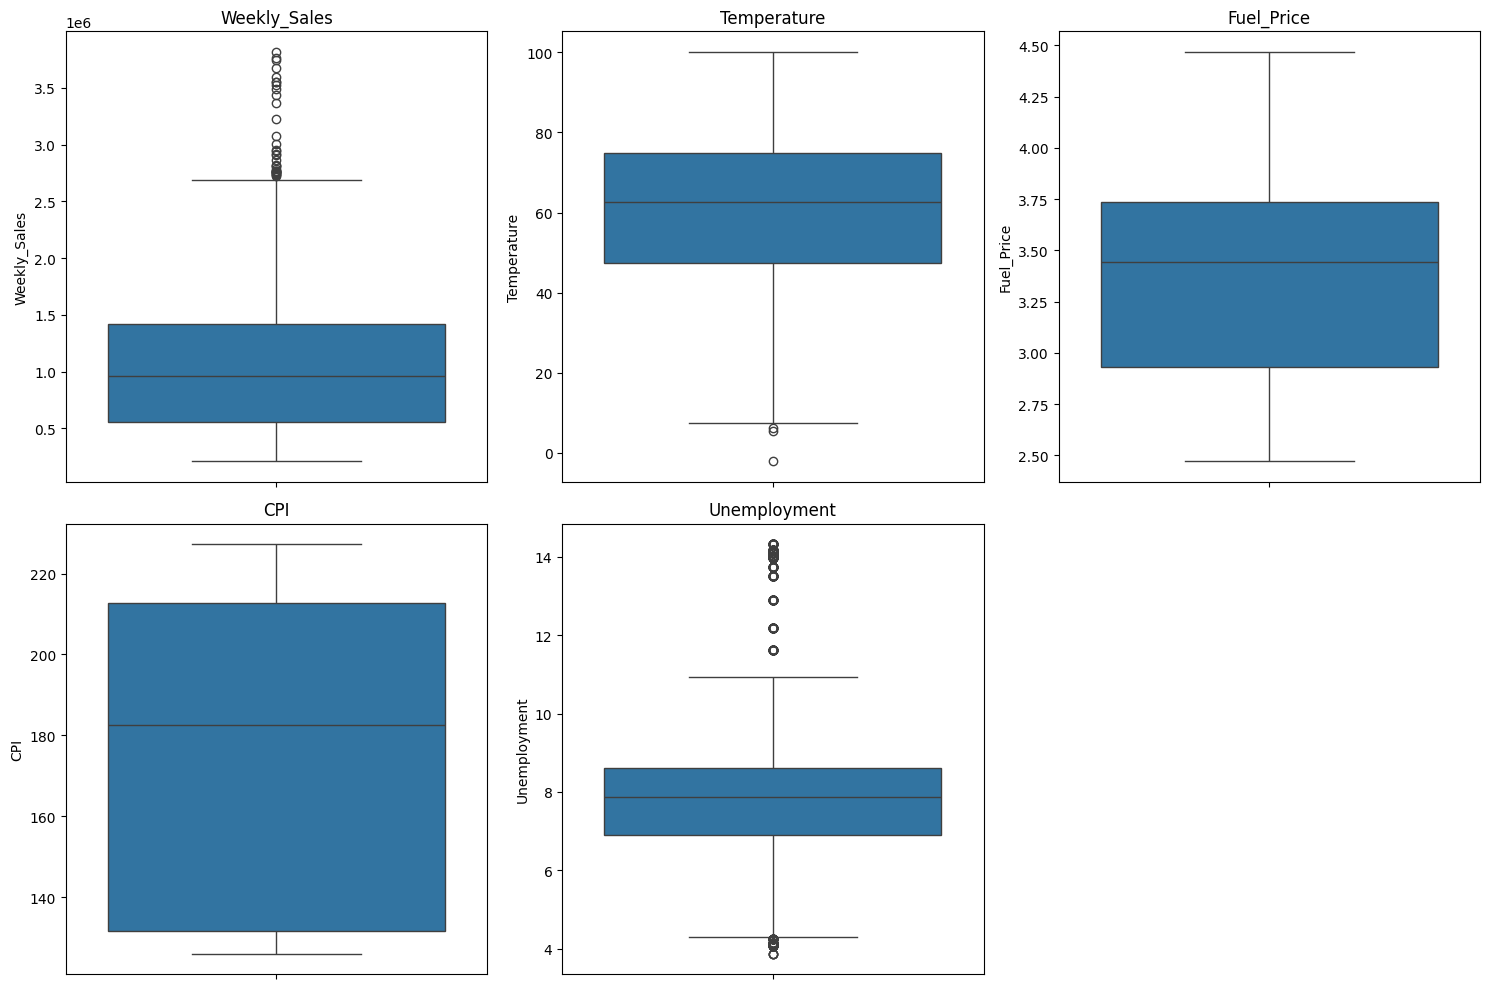

Выбросы в Weekly_Sales: 34
Выбросы в Temperature: 3
Выбросы в Fuel_Price: 0
Выбросы в CPI: 0
Выбросы в Unemployment: 481


In [7]:
def iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

numeric_columns = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'{col}')

plt.tight_layout()
plt.show()

for col in numeric_columns:
    outliers, lower_bound, upper_bound = iqr(df, col)
    print(f"Выбросы в {col}: {len(outliers)}")
    df[col] = np.where(df[col] > upper_bound, upper_bound, 
                      np.where(df[col] < lower_bound, lower_bound, df[col]))

In [8]:
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")
df['Store'] = df['Store'].astype('category')
df['Holiday_Flag'] = df['Holiday_Flag'].astype('category')

print(df.dtypes)

Store                 category
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag          category
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object


In [9]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['DayOfYear'] = df['Date'].dt.dayofyear
df['IsWeekend'] = (df['Date'].dt.dayofweek >= 5).astype(int)

df['Season'] = df['Month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                               3: 'Spring', 4: 'Spring', 5: 'Spring',
                               6: 'Summer', 7: 'Summer', 8: 'Summer',
                               9: 'Autumn', 10: 'Autumn', 11: 'Autumn'})


df = df.sort_values(['Store', 'Date'])
df['Sales_Lag_1'] = df.groupby('Store')['Weekly_Sales'].shift(1)
df['Sales_Lag_1'] = df.groupby('Store')['Sales_Lag_1'].transform(
    lambda x: x.fillna(x.median()))
df['Sales_Lag_4'] = df.groupby('Store')['Weekly_Sales'].shift(4) 
df['Sales_Lag_4'] = df.groupby('Store')['Sales_Lag_4'].transform(
    lambda x: x.fillna(x.median()))
df['Sales_Lag_52'] = df.groupby('Store')['Weekly_Sales'].shift(52)  
df['Sales_Lag_52'] = df.groupby('Store')['Sales_Lag_52'].transform(
    lambda x: x.fillna(x.median()))



df['Sales_Mean_4'] = df.groupby('Store')['Weekly_Sales'].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean())
df['Sales_Mean_12'] = df.groupby('Store')['Weekly_Sales'].transform(
    lambda x: x.rolling(window=12, min_periods=1).mean())


store_stats = df.groupby('Store').agg({
    'Weekly_Sales': ['mean', 'min', 'max'],
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean'
}).round(2)
store_stats.columns = ['_'.join(col).strip() for col in store_stats.columns.values]


df = df.merge(store_stats, on='Store', how='left')


df['Sales_Trend'] = df.groupby('Store')['Weekly_Sales'].transform(
    lambda x: x.diff().rolling(window=4, min_periods=1).mean())
df


C:\Users\anyab\AppData\Local\Temp\ipykernel_32488\359214332.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['Sales_Lag_1'] = df.groupby('Store')['Weekly_Sales'].shift(1)
C:\Users\anyab\AppData\Local\Temp\ipykernel_32488\359214332.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['Sales_Lag_1'] = df.groupby('Store')['Sales_Lag_1'].transform(
C:\Users\anyab\AppData\Local\Temp\ipykernel_32488\359214332.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt t

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,...,Sales_Mean_4,Sales_Mean_12,Weekly_Sales_mean,Weekly_Sales_min,Weekly_Sales_max,Temperature_mean,Fuel_Price_mean,CPI_mean,Unemployment_mean,Sales_Trend
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,...,1.643691e+06,1.643691e+06,1555264.40,1316899.31,2387950.20,68.31,3.22,216.00,7.61,NaN
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,...,1.642824e+06,1.642824e+06,1555264.40,1316899.31,2387950.20,68.31,3.22,216.00,7.61,-1733.4600
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,...,1.632539e+06,1.632539e+06,1555264.40,1316899.31,2387950.20,68.31,3.22,216.00,7.61,-15861.3650
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,...,1.576836e+06,1.576836e+06,1555264.40,1316899.31,2387950.20,68.31,3.22,216.00,7.61,-77987.7700
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,...,1.554615e+06,1.572430e+06,1555264.40,1316899.31,2387950.20,68.31,3.22,216.00,7.61,-22221.0550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,2012,9,...,7.262528e+05,7.281589e+05,785981.41,617207.58,1682862.03,57.79,3.42,186.29,8.65,-5280.9800
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,2012,10,...,7.179884e+05,7.267954e+05,785981.41,617207.58,1682862.03,57.79,3.42,186.29,8.65,-8264.3975
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,2012,10,...,7.260449e+05,7.265330e+05,785981.41,617207.58,1682862.03,57.79,3.42,186.29,8.65,8056.5225
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,2012,10,...,7.248047e+05,7.270708e+05,785981.41,617207.58,1682862.03,57.79,3.42,186.29,8.65,-1240.1675



 Temperature:
   Асимметрия: -0.33 


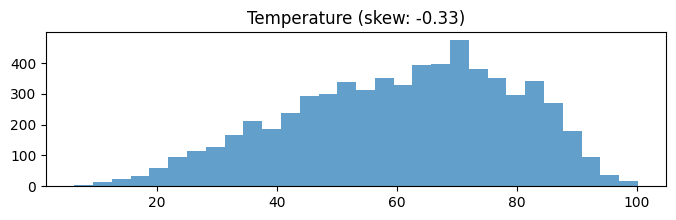

StandardScaler

 Fuel_Price:
   Асимметрия: -0.10 


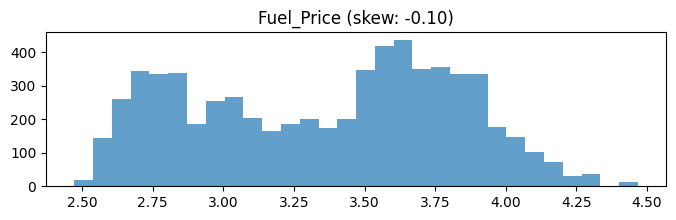

StandardScaler

 CPI:
   Асимметрия: 0.06 


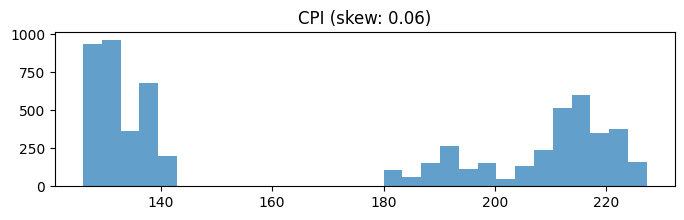

StandardScaler

 Unemployment:
   Асимметрия: 0.18 


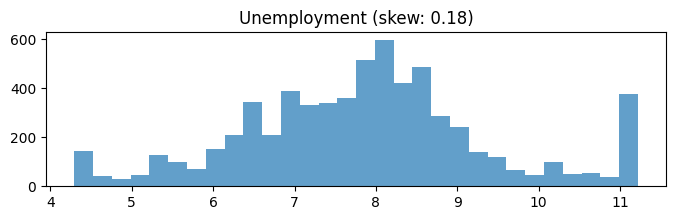

StandardScaler

 Sales_Lag_1:
   Асимметрия: 0.56 


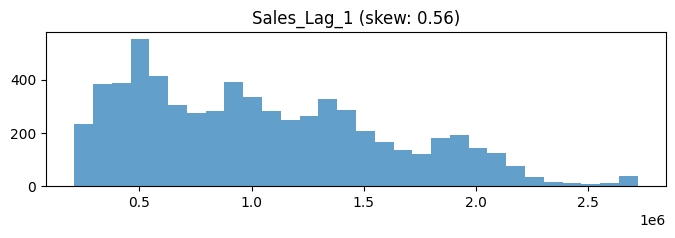

PowerTransformer

 Sales_Lag_4:
   Асимметрия: 0.56 


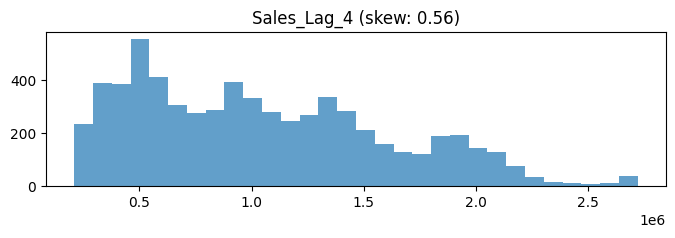

PowerTransformer

 Sales_Lag_52:
   Асимметрия: 0.52 


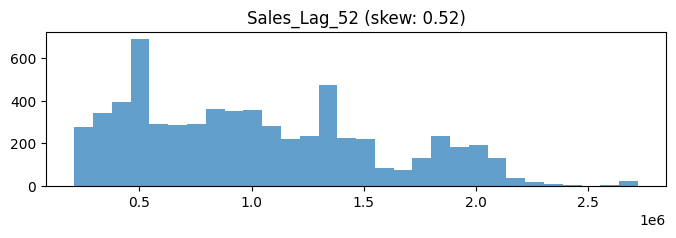

PowerTransformer

 Sales_Mean_4:
   Асимметрия: 0.48 


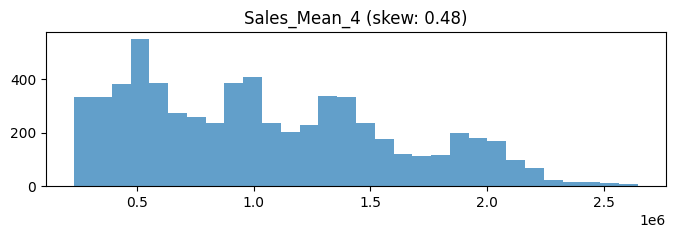

StandardScaler

 Sales_Mean_12:
   Асимметрия: 0.44 


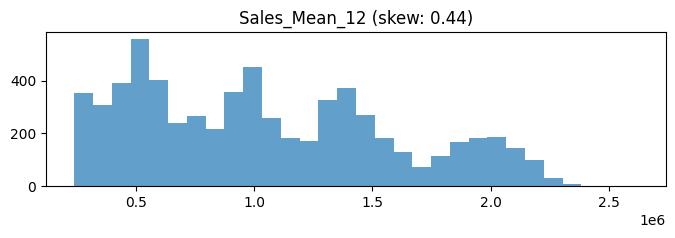

StandardScaler


In [10]:
features =  ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 
                   'Sales_Lag_1', 'Sales_Lag_4', 'Sales_Lag_52',
                   'Sales_Mean_4', 'Sales_Mean_12']

for feature in features:
    data = df[feature].dropna()
    
    skew_val = data.skew()
    print(f"\n {feature}:")
    print(f"   Асимметрия: {skew_val:.2f} ")
    
    plt.figure(figsize=(8, 2))
    plt.hist(data, bins=30, alpha=0.7)
    plt.title(f'{feature} (skew: {skew_val:.2f})')
    plt.show()
    
    if abs(skew_val) < 0.5:
        print("StandardScaler")
    elif abs(skew_val) > 1 :
        print("RobustScaler") 
    else:
        print("PowerTransformer")


In [11]:
for col in numeric_features:
    df[col] = df.groupby('Store')[col].transform(
        lambda x: x.fillna(x.median()))
numeric_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 
                   'Sales_Lag_1', 'Sales_Lag_4', 'Sales_Lag_52',
                   'Sales_Mean_4', 'Sales_Mean_12', 'Sales_Trend']

df_clean = df.dropna(subset=numeric_features)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_clean[numeric_features])

scaled_df = pd.DataFrame(scaled_features, columns=[f'{col}_scaled' for col in numeric_features])
scaled_df.index = df_clean.index

df = pd.concat([df, scaled_df], axis=1)
print("Готово")

NameError: name 'numeric_features' is not defined

In [ ]:
season_dummies = pd.get_dummies(df['Season'], prefix='Season')
df = pd.concat([df, season_dummies], axis=1)

le = LabelEncoder()
df['Store_encoded'] = le.fit_transform(df['Store'])


Размер: (6435, 42)

Пропущенные значения:
0


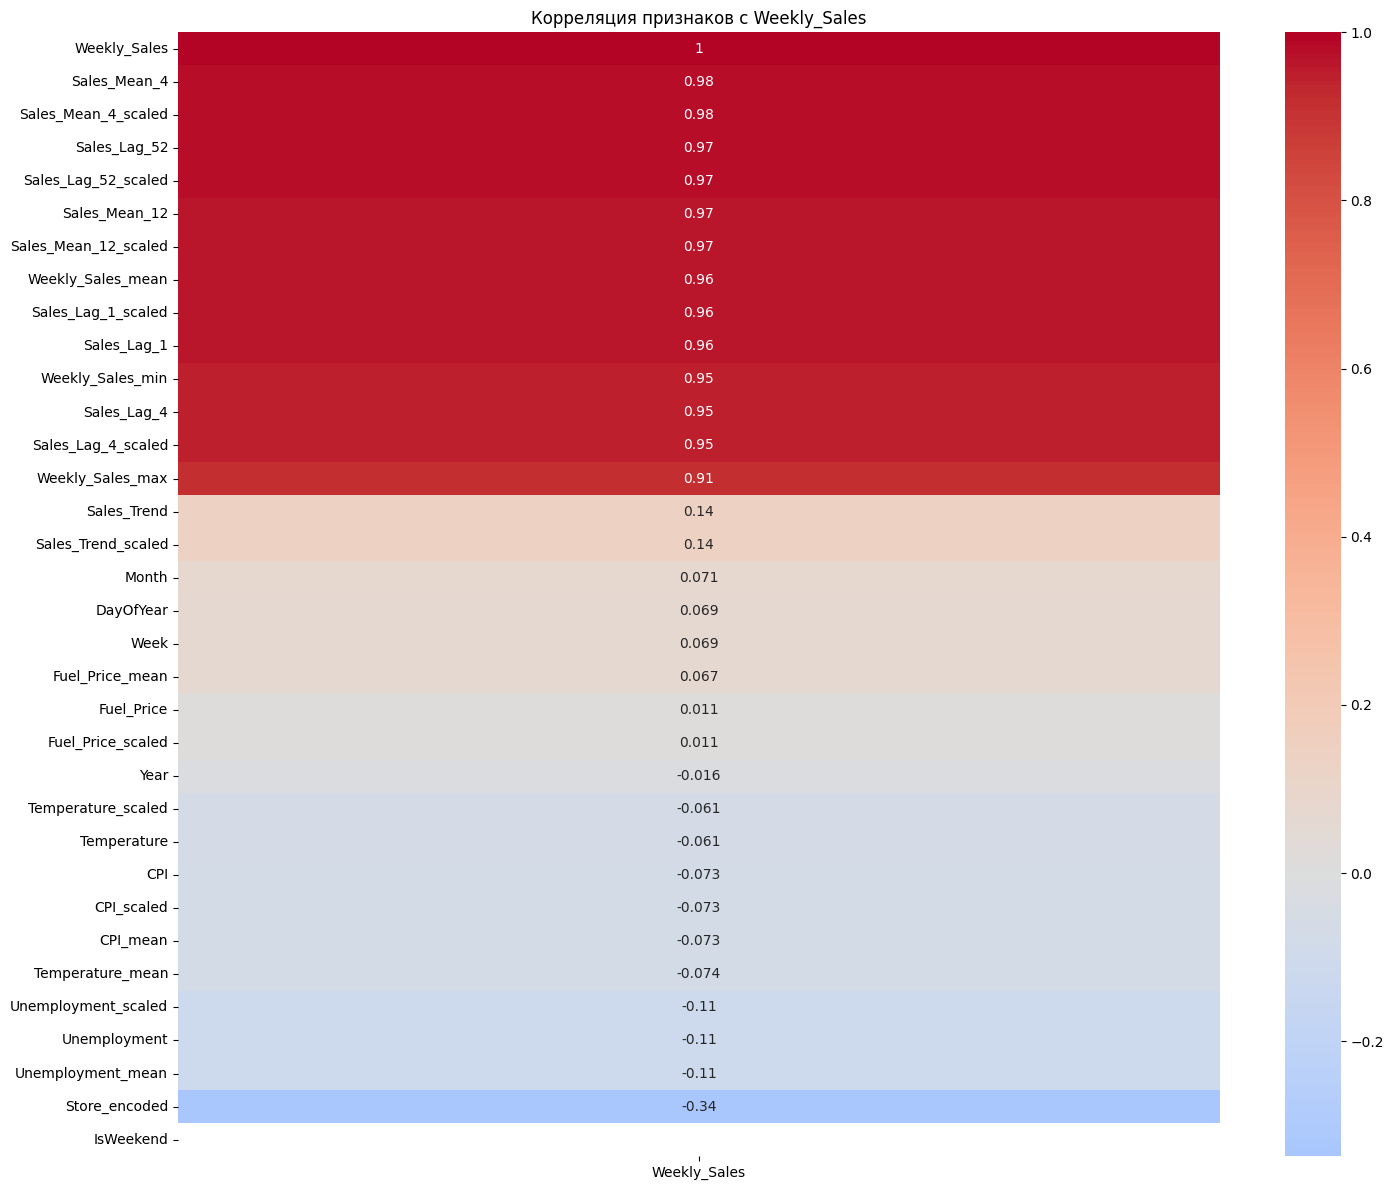

In [ ]:
print(f"Размер: {df.shape}")
print("\nПропущенные значения:")
print(df.isnull().sum().sum())

df.to_csv('Walmart_cleaned.csv', index=False)

plt.figure(figsize=(15, 12))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix[['Weekly_Sales']].sort_values('Weekly_Sales', ascending=False), 
            annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция признаков с Weekly_Sales')
plt.tight_layout()
plt.show()